### Problem Statement: The objective of this project is to develop a Machine Learning model that can predict the price of a flight ticket using airline, source and destination cities, departure and arrival times and other features. The model can help passengers estimate ticket prices in advance and help airlines understand the factors that influence ticket pricing.

### Import libraries and load dataset

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')

In [48]:
df= pd.read_csv(r"Flight_Ticket_price.csv",index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Understand the dataset

In [49]:
df.shape

(300153, 11)

In [50]:
df.dtypes

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [51]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [52]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


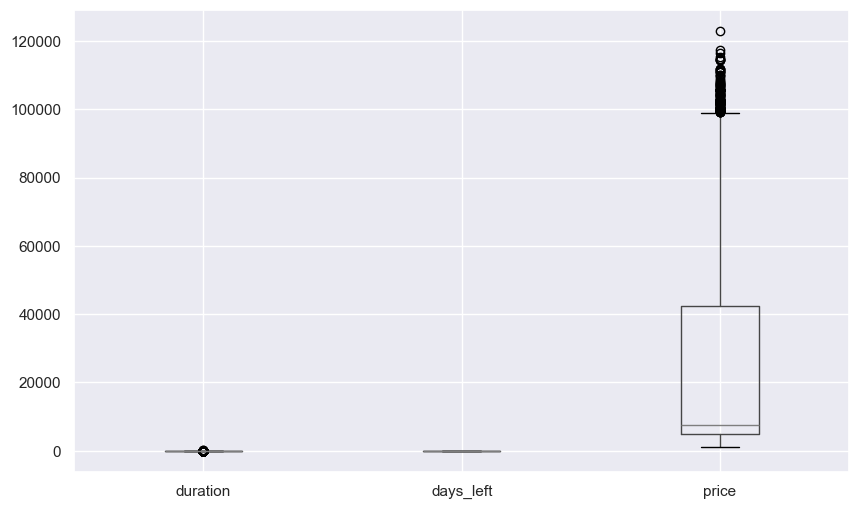

In [55]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

### Drop Unnecessory columns

In [56]:
df.drop(columns=['flight'],inplace=True)

In [57]:
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Encoding for categorical columns

In [58]:
cols=['airline','source_city','destination_city']
cols

['airline', 'source_city', 'destination_city']

In [59]:
for i in cols:
    print(df[i].unique())
    

['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']


In [60]:
oe=OrdinalEncoder()
df[cols]=oe.fit_transform(df[cols])
df.head()


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4.0,2.0,Evening,zero,Night,5.0,Economy,2.17,1,5953
1,4.0,2.0,Early_Morning,zero,Morning,5.0,Economy,2.33,1,5953
2,0.0,2.0,Early_Morning,zero,Early_Morning,5.0,Economy,2.17,1,5956
3,5.0,2.0,Morning,zero,Afternoon,5.0,Economy,2.25,1,5955
4,5.0,2.0,Morning,zero,Morning,5.0,Economy,2.33,1,5955


In [61]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [62]:
df.groupby('departure_time')['price'].mean().sort_values(ascending=False)

departure_time
Night            23062.146808
Morning          21630.760254
Evening          21232.361894
Early_Morning    20370.676718
Afternoon        18179.203331
Late_Night        9295.299387
Name: price, dtype: float64

In [63]:
df['departure_time']=df['departure_time'].map({'Early_Morning':2,'Late_Night':0,
                                              'Morning':4,'Afternoon':1,'Night':5,'Evening':3})

df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4.0,2.0,3,zero,Night,5.0,Economy,2.17,1,5953
1,4.0,2.0,2,zero,Morning,5.0,Economy,2.33,1,5953
2,0.0,2.0,2,zero,Early_Morning,5.0,Economy,2.17,1,5956
3,5.0,2.0,4,zero,Afternoon,5.0,Economy,2.25,1,5955
4,5.0,2.0,4,zero,Morning,5.0,Economy,2.33,1,5955


In [64]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [65]:
df['stops']=df['stops'].map({'zero':2,'one':1,'two_or_more':0})
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4.0,2.0,3,2,Night,5.0,Economy,2.17,1,5953
1,4.0,2.0,2,2,Morning,5.0,Economy,2.33,1,5953
2,0.0,2.0,2,2,Early_Morning,5.0,Economy,2.17,1,5956
3,5.0,2.0,4,2,Afternoon,5.0,Economy,2.25,1,5955
4,5.0,2.0,4,2,Morning,5.0,Economy,2.33,1,5955


In [66]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [67]:
df['arrival_time']=df['arrival_time'].map({'Early_Morning':2,'Late_Night':0,
                                              'Morning':4,'Afternoon':1,'Night':5,'Evening':3})

df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4.0,2.0,3,2,5,5.0,Economy,2.17,1,5953
1,4.0,2.0,2,2,4,5.0,Economy,2.33,1,5953
2,0.0,2.0,2,2,2,5.0,Economy,2.17,1,5956
3,5.0,2.0,4,2,1,5.0,Economy,2.25,1,5955
4,5.0,2.0,4,2,4,5.0,Economy,2.33,1,5955


In [68]:
df['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [69]:
df['class']=df['class'].map({'Economy':0,'Business':1})
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4.0,2.0,3,2,5,5.0,0,2.17,1,5953
1,4.0,2.0,2,2,4,5.0,0,2.33,1,5953
2,0.0,2.0,2,2,2,5.0,0,2.17,1,5956
3,5.0,2.0,4,2,1,5.0,0,2.25,1,5955
4,5.0,2.0,4,2,4,5.0,0,2.33,1,5955


### Outlier of 'Duration' column


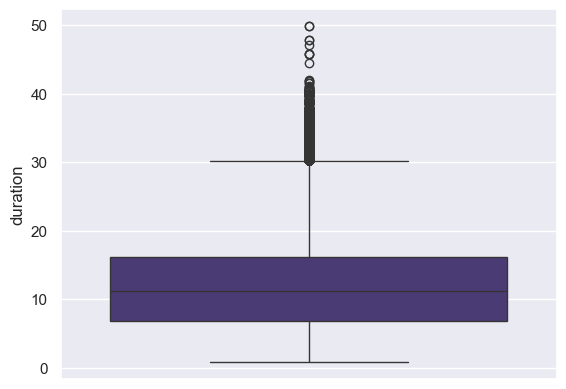

In [70]:
sns.boxplot(df['duration'])
plt.show()

In [71]:
q1=df['duration'].quantile(0.25)

In [72]:
q3=df['duration'].quantile(0.75)

In [73]:
iqr=q3-q1
iqr

np.float64(9.340000000000002)

In [74]:
lower=q1-(1.5*iqr)
upper=q3+(1.5*iqr)
lower,upper

(np.float64(-7.1800000000000015), np.float64(30.180000000000003))

In [75]:
df['duration']=np.clip(df['duration'],lower,upper)

<Axes: ylabel='duration'>

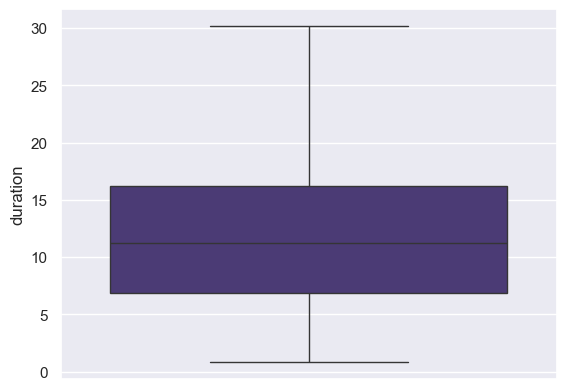

In [76]:
sns.boxplot(df['duration'])

### Define x and y

In [77]:
x=df.iloc[:,:-1]
y=df['price']

### Split Data for training and testing 

In [78]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=42)


### Train the model

In [79]:
dtr= DecisionTreeRegressor(random_state=42)
dtr.fit(xtrain,ytrain)

DecisionTreeRegressor(random_state=42)

In [80]:
ypred=dtr.predict(xtest)
ypred

array([ 7366., 72783.,  6195., ...,  6314.,  2815., 70049.])

### Check R2 score

In [81]:
r2_score(ytest,ypred)

0.976409226536758

In [82]:
print("Train Accuracy :",dtr.score(xtrain,ytrain))
print("Test Accuracy :",dtr.score(xtest,ytest))

Train Accuracy : 0.9992857914763827
Test Accuracy : 0.976409226536758


<p> Conclusion:The Decision Tree Regressor was successfully implemented to predict flight ticket prices using factors such as airline, source city, destination city, departure time, arrival time, number of stops, class, duration, and days left before departure.
The Decision Tree Regressor achieved a training R² score of 99.93% and a testing R² score of 97.64%. The high test R² indicates that the model is able to explain approximately 97.64% of the variation in flight ticket prices on unseen data. 
</p>